In [2]:
from probjax.core.utils import BaseInterpreter, BaseRules
from probjax.core.random_variable import rv, rv_p

from probjax.distributions import Normal

import jax 
from jax.core import Literal, Jaxpr
import jax.numpy as jnp
import jax.random as jrandom

import networkx as nx


No GPU/TPU found, falling back to CPU. (Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


In [ ]:

import jax
from jax import core
from graphviz import Digraph
import itertools

styles = {
  'const': dict(style='', color='goldenrod1'),
  'invar': dict(color='mediumspringgreen', style='filled'),
  'outvar': dict(style='filled,dashed', fillcolor='indianred1', color='black'),
  'op_node': dict(shape='box', color='lightskyblue', style='filled'),
  'intermediate': dict(style='filled', color='cornflowerblue')
}


def _jaxpr_graph(jaxpr):
  id_names = (f'id{id}' for id in itertools.count())
  graph = Digraph(engine='dot')
  graph.attr(size='6,10!')
  for v in jaxpr.constvars:
    graph.node(str(v), core.raise_to_shaped(v.aval).str_short(), styles['const'])
  for v in jaxpr.invars:
    graph.node(str(v), v.aval.str_short(), styles['invar'])
  for eqn in jaxpr.eqns:
    for v in eqn.invars:
      if isinstance(v, core.Literal):
        graph.node(str(id(v.val)), core.raise_to_shaped(core.get_aval(v.val)).str_short(),
                   styles['const'])
    if eqn.primitive.multiple_results:
      id_name = next(id_names)
      graph.node(id_name, str(eqn.primitive), styles['op_node'])
      for v in eqn.invars:
        graph.edge(str(id(v.val) if isinstance(v, core.Literal) else v), id_name)
      for v in eqn.outvars:
        graph.node(str(v), v.aval.str_short(), styles['intermediate'])
        graph.edge(id_name, str(v))
    else:
      outv, = eqn.outvars
      graph.node(str(outv), str(eqn.primitive), styles['op_node'])
      for v in eqn.invars:
        graph.edge(str(id(v.val) if isinstance(v, core.Literal) else v), str(outv))
  for i, v in enumerate(jaxpr.outvars):
    outv = 'out_'+str(i)
    graph.node(outv, outv, styles['outvar'])
    graph.edge(str(v), outv)
  return graph



In [ ]:
def _jaxpr_graph(jaxpr):
  id_names = (f'id{id}' for id in itertools.count())
  graph = Digraph(engine='dot')
  graph.attr(size='6,10!')
  for v in jaxpr.constvars:
    graph.node(str(v), core.raise_to_shaped(v.aval).str_short(), styles['const'])
  for v in jaxpr.invars:
    graph.node(str(v), v.aval.str_short(), styles['invar'])
  for eqn in jaxpr.eqns:
    for v in eqn.invars:
      if isinstance(v, core.Literal):
        graph.node(str(id(v.val)), core.raise_to_shaped(core.get_aval(v.val)).str_short(),
                   styles['const'])
    if eqn.primitive.multiple_results:
      id_name = next(id_names)
      graph.node(id_name, str(eqn.primitive), styles['op_node'])
      for v in eqn.invars:
        graph.edge(str(id(v.val) if isinstance(v, core.Literal) else v), id_name)
      for v in eqn.outvars:
        graph.node(str(v), v.aval.str_short(), styles['intermediate'])
        graph.edge(id_name, str(v))
    else:
      outv, = eqn.outvars
      graph.node(str(outv), str(eqn.primitive), styles['op_node'])
      for v in eqn.invars:
        graph.edge(str(id(v.val) if isinstance(v, core.Literal) else v), str(outv))
  for i, v in enumerate(jaxpr.outvars):
    outv = 'out_'+str(i)
    graph.node(outv, outv, styles['outvar'])
    graph.edge(str(v), outv)
  return graph

In [307]:
# import io
# graph = FactorGraph(jaxpr)
# AGraph = nx.nx_agraph.to_agraph(graph.graph)
# AGraph.layout('dot')
# svg  = io.BytesIO()
# AGraph.draw(svg, format='svg')
# svg.seek(0)
# SVG(svg.read())

In [330]:
from IPython.display import display, SVG
import io
import matplotlib.pyplot as plt


NODE_STYLES = {
  'const': dict(style='', color='goldenrod1', shape="circle", fontsize=9, margin=0.01,width=0.2, height=0.2, regular=True),
  'invar': dict(fillcolor='mediumspringgreen', style='filled', shape="circle", fontsize=9,width=0.2, height=0.2, margin=0.01, regular=True),
  'outvar': dict(style='filled', fillcolor='indianred1', color='black', shape="circle",width=0.2, height=0.2, fontsize=9, margin=0.01, regular=True),
  'operation': dict(shape='box', color='black', fontsize=9, regular=True, margin=0.01,width=0.2, height=0.2),
  'random_variable': dict(shape='circle', style='bold',width=0.2, height=0.2),
  'latent': dict(style='filled', color='cornflowerblue', shape="circle", width=0.2, height=0.2, fontsize=8, margin=0.01, regular=True),
}

def eqn_pretty_print(eqn):
    name = eqn.primitive.name
    if name == "integer_pow":
        y = eqn.params["y"]
        return f"pow(2)"
    elif name == "convert_element_type":
        return str(eqn.params["new_dtype"])
    elif name == "broadcast_in_dim":
        return f"broadcast"
    elif name == "concatenate":
        return "concat"
    else:
        return name


class FactorGraph():
    def __init__(self, jaxpr) -> None:
        self.graph = nx.DiGraph()
        
        for n in jaxpr.constvars:
            self.graph.add_node(str(n), tag='const', value=n, **NODE_STYLES["const"])

        for n in jaxpr.invars:
            self.graph.add_node(str(n), tag='invar', value=n, **NODE_STYLES["invar"])

        for n in jaxpr.outvars:
            self.graph.add_node(str(n), tag='outvar', value=n, **NODE_STYLES["outvar"])

        for i,eqn in enumerate(jaxpr.eqns):

            # Add operation node -> here an actual operation is run
            if eqn.primitive is rv_p:
                self.graph.add_node(f"f{i}", tag='operation', value=eqn, xlabel=eqn_pretty_print(eqn), **NODE_STYLES["operation"])
            else:
                self.graph.add_node(f"f{i}", tag='operation', value=eqn, xlabel=eqn_pretty_print(eqn), **NODE_STYLES["operation"])

            # Add invars
            in_vars = eqn.invars
            for n in in_vars:
                if str(n) not in self.graph.nodes:
                    self.graph.add_node(str(n), tag='latent', value=n, **NODE_STYLES["latent"])

                self.graph.add_edge(str(n), f"f{i}")
            # Add outvars
            out_vars = eqn.outvars
            for n in out_vars:
                if str(n) not in self.graph.name:
                    self.graph.add_node(str(n), tag='latent', value=n, **NODE_STYLES["latent"])
                
                self.graph.add_edge(f"f{i}", str(n))

    


    def __repr__(self):
        AGraph = nx.nx_agraph.to_agraph(self.graph)
        AGraph.graph_attr["rankdir"] = 'LR'
        AGraph.layout('dot')
        svg  = io.BytesIO()
        AGraph.draw(svg, format='svg')
        svg.seek(0)
        display(SVG(svg.read()))
        return ''
            


In [1]:
jax.tree_util.tree_flatten(params)

NameError: name 'jax' is not defined

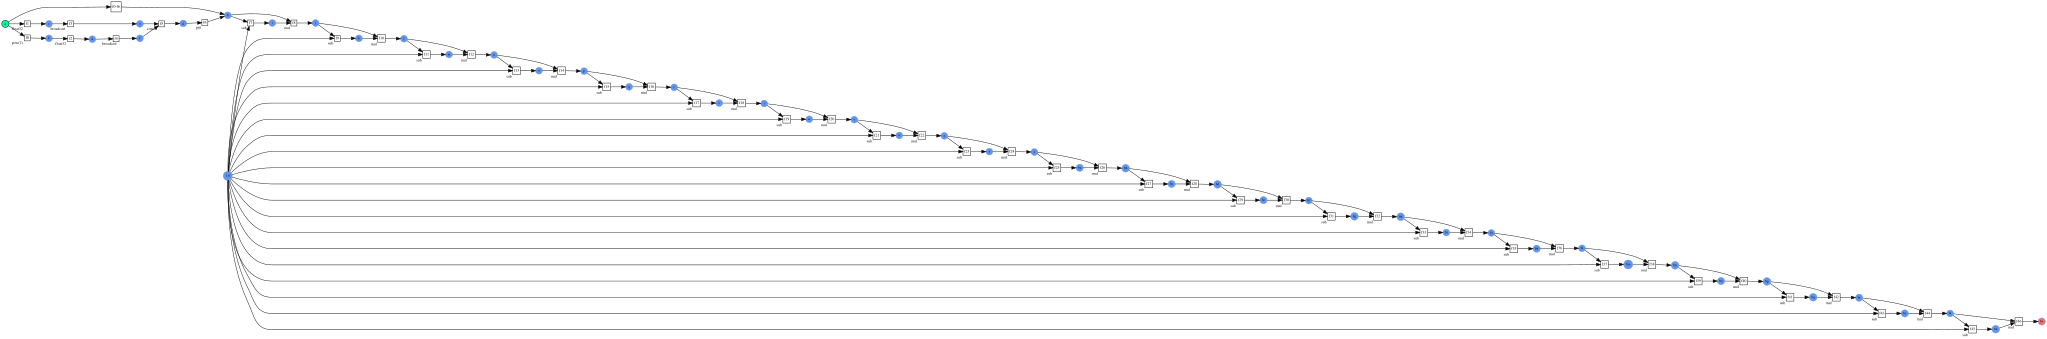

In [392]:
G = graph.graph

eqns_group = ["f0", "f1", "f2", "f3", "f4", "f5", "f6"]

start_node = G.nodes["f0"]
end_node = G.nodes["f6"]

predecessor_start = list(G.predecessors(eqns_group[0]))
successor_end = list(G.successors(eqns_group[-1]))

G.add_node(f"{eqns_group[0]}-{eqns_group[-1]}", **NODE_STYLES["operation"])
for n in predecessor_start:
    G.add_edge(n,f"{eqns_group[0]}-{eqns_group[-1]}")
for n in successor_end:
    G.add_edge(f"{eqns_group[0]}-{eqns_group[-1]}", n)

graph

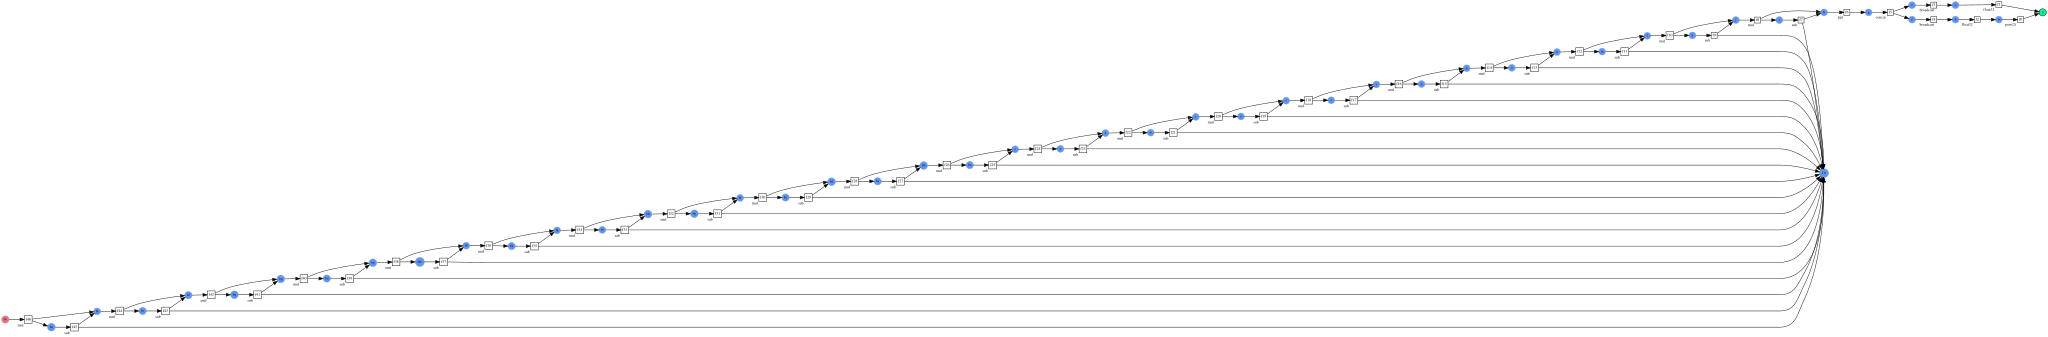

In [437]:
graph.graph = nx.reverse_view(G)
graph

In [430]:
graph = FactorGraph(jaxpr)

G= graph.graph

edges = nx.bfs_edges(G, "a")

for e in edges:
    print(e)

('a', 'f0')
('a', 'f1')
('f0', 'b')
('f1', 'c')
('b', 'f2')
('c', 'f3')
('f2', 'd')
('f3', 'e')
('d', 'f4')
('e', 'f5')
('f4', 'f')
('f5', 'g')
('g', 'f6')
('f6', 'h')
('h', 'f7')
('h', 'f8')
('f7', 'i')
('f8', 'j')
('j', 'f9')
('j', 'f10')
('f9', 'k')
('f10', 'l')
('l', 'f11')
('l', 'f12')
('f11', 'm')
('f12', 'n')
('n', 'f13')
('n', 'f14')
('f13', 'o')
('f14', 'p')
('p', 'f15')
('p', 'f16')
('f15', 'q')
('f16', 'r')
('r', 'f17')
('r', 'f18')
('f17', 's')
('f18', 't')
('t', 'f19')
('t', 'f20')
('f19', 'u')
('f20', 'v')
('v', 'f21')
('v', 'f22')
('f21', 'w')
('f22', 'x')
('x', 'f23')
('x', 'f24')
('f23', 'y')
('f24', 'z')
('z', 'f25')
('z', 'f26')
('f25', 'ba')
('f26', 'bb')
('bb', 'f27')
('bb', 'f28')
('f27', 'bc')
('f28', 'bd')
('bd', 'f29')
('bd', 'f30')
('f29', 'be')
('f30', 'bf')
('bf', 'f31')
('bf', 'f32')
('f31', 'bg')
('f32', 'bh')
('bh', 'f33')
('bh', 'f34')
('f33', 'bi')
('f34', 'bj')
('bj', 'f35')
('bj', 'f36')
('f35', 'bk')
('f36', 'bl')
('bl', 'f37')
('bl', 'f38')
('f37', 

In [401]:
?nx.subgraph

Signature: nx.subgraph(G, nbunch)
Docstring:
Returns the subgraph induced on nodes in nbunch.

Parameters
----------
G : graph
   A NetworkX graph

nbunch : list, iterable
   A container of nodes that will be iterated through once (thus
   it should be an iterator or be iterable).  Each element of the
   container should be a valid node type: any hashable type except
   None.  If nbunch is None, return all edges data in the graph.
   Nodes in nbunch that are not in the graph will be (quietly)
   ignored.

Notes
-----
subgraph(G) calls G.subgraph()
File:      ~/.local/lib/python3.10/site-packages/networkx/classes/function.py
Type:      function

In [396]:
graph = FactorGraph(jaxpr)
#graph

In [236]:
hash(str(jaxpr.eqns[0]))

-4505607412573800168

In [16]:
dict ={jaxpr.eqns[0]: 1}

TypeError: unhashable type: 'list'

In [302]:
def g(y):
    z = y + 1
    return z

def f(x):
    y = x**2
    z = jax.jit(g)(jnp.array([x,y]))
    for i in range(20):
        z = z*(z-1)
    return z

In [303]:
jaxpr = jax.make_jaxpr(f)(2.0).jaxpr
graph =  _jaxpr_graph(jaxpr)
jaxpr

{ lambda ; a:f32[]. let
    b:f32[] = integer_pow[y=2] a
    c:f32[] = convert_element_type[new_dtype=float32 weak_type=False] a
    d:f32[] = convert_element_type[new_dtype=float32 weak_type=False] b
    e:f32[1] = broadcast_in_dim[broadcast_dimensions=() shape=(1,)] c
    f:f32[1] = broadcast_in_dim[broadcast_dimensions=() shape=(1,)] d
    g:f32[2] = concatenate[dimension=0] e f
    h:f32[2] = pjit[
      jaxpr={ lambda ; i:f32[2]. let j:f32[2] = add i 1.0 in (j,) }
      name=g
    ] g
    k:f32[2] = sub h 1.0
    l:f32[2] = mul h k
    m:f32[2] = sub l 1.0
    n:f32[2] = mul l m
    o:f32[2] = sub n 1.0
    p:f32[2] = mul n o
    q:f32[2] = sub p 1.0
    r:f32[2] = mul p q
    s:f32[2] = sub r 1.0
    t:f32[2] = mul r s
    u:f32[2] = sub t 1.0
    v:f32[2] = mul t u
    w:f32[2] = sub v 1.0
    x:f32[2] = mul v w
    y:f32[2] = sub x 1.0
    z:f32[2] = mul x y
    ba:f32[2] = sub z 1.0
    bb:f32[2] = mul z ba
    bc:f32[2] = sub bb 1.0
    bd:f32[2] = mul bb bc
    be:f32[2] = s

In [52]:
Jaxpr(invars = jaxpr.eqns[1].invars, outvars=jaxpr.eqns[-1].outvars, eqns=jaxpr.eqns[1:], constvars=jaxpr.constvars)

{ lambda ; a:f32[]. let
    b:f32[] = convert_element_type[new_dtype=float32 weak_type=False] a
    c:f32[] = convert_element_type[new_dtype=float32 weak_type=False] d
    e:f32[1] = broadcast_in_dim[broadcast_dimensions=() shape=(1,)] b
    f:f32[1] = broadcast_in_dim[broadcast_dimensions=() shape=(1,)] c
    g:f32[2] = concatenate[dimension=0] e f
    h:f32[2] = pjit[
      jaxpr={ lambda ; i:f32[2]. let j:f32[2] = add i 1.0 in (j,) }
      name=g
    ] g
  in (h,) }

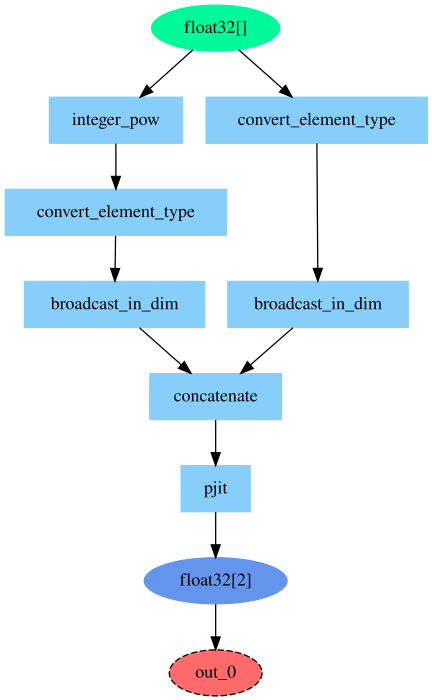

In [53]:
graph